# 10a — Correlation and agreement

**Theme:** do two instruments measuring the same air report the same thing?

This is the usual first step of an intercomparison: run two instruments side by
side, then quantify how they relate. The follow-on — turning a measured
disagreement into a correction — is
[10b — Calibration](10b-calibration.ipynb).

In [1]:
import aerosoltools as at

ns1 = at.load_ns_file("../../tests/data/Combine_example_NS.csv")
ns2 = at.load_ns_file("../../tests/data/Correlation_example_NS2.csv")

print(f"instrument 1: {len(ns1.data)} samples, {ns1.time[0]} -> {ns1.time[-1]}")
print(f"instrument 2: {len(ns2.data)} samples, {ns2.time[0]} -> {ns2.time[-1]}")

instrument 1: 23121 samples, 2023-05-30 15:41:29 -> 2023-12-06 10:19:42
instrument 2: 8626 samples, 2023-05-08 21:26:14 -> 2023-11-02 12:29:16


/opt/hostedtoolcache/Python/3.11.15/x64/lib/python3.11/site-packages/tqdm/auto.py:21: TqdmWarning: IProgress not found. Please update jupyter and ipywidgets. See https://ipywidgets.readthedocs.io/en/stable/user_install.html
  from .autonotebook import tqdm as notebook_tqdm


## Aligning in time first

Two instruments rarely share timestamps exactly. Every function here takes a
`match` argument:

- `"exact"` (default) — keep only timestamps present in both
- `"nearest"` — pair each sample with the closest one within `tolerance`
- `"rebin"` — put both onto a common grid, set by `rebin_freq`

With clocks that differ by seconds, `"exact"` finds nothing at all, so
`"nearest"` is usually the right choice.

## Correlation

`plot_correlation` fits a regression, draws the 1:1 line for reference, and
reports R².

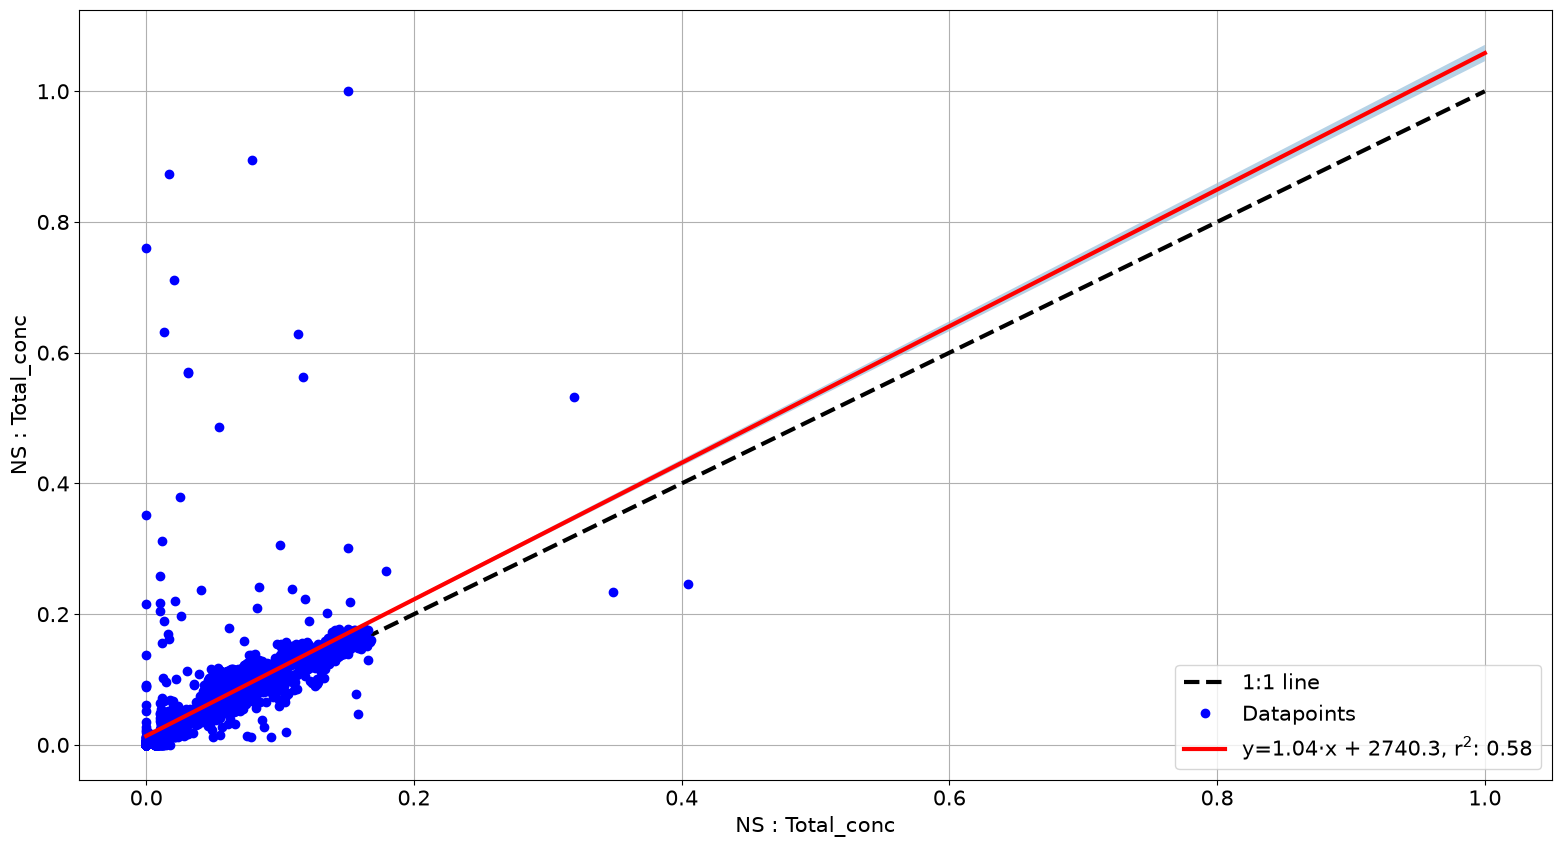

In [2]:
fig, ax = at.plot_correlation(ns1, ns2, match="nearest", tolerance="45s")

Restricting to a period when both instruments sampled the same air — a
side-by-side run before the experiment — gives a cleaner comparison than the
whole record.

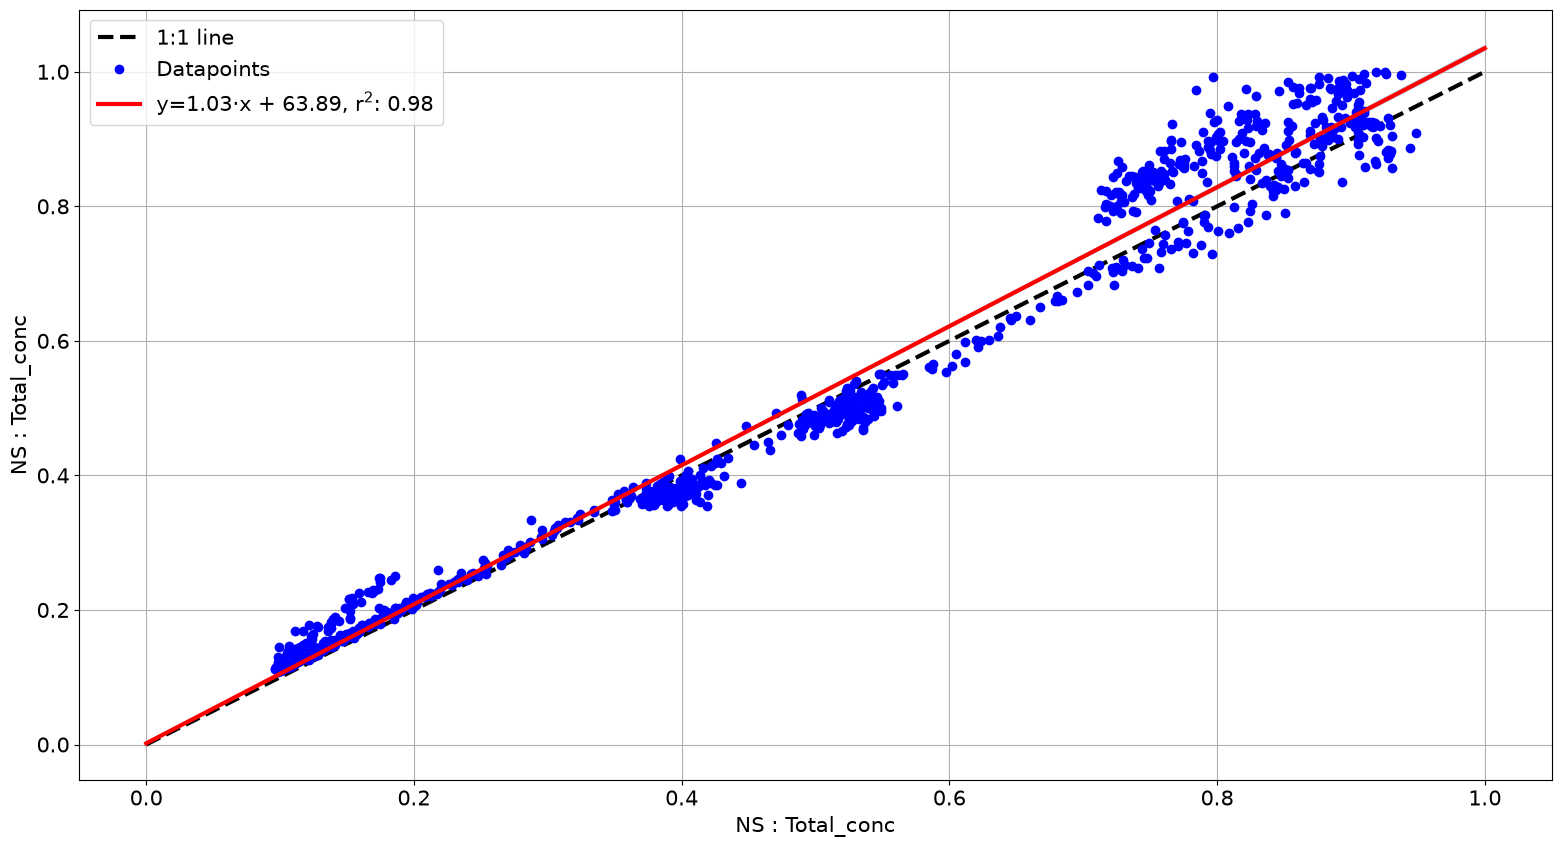

In [3]:
fig, ax = at.plot_correlation(
    ns1, ns2,
    start_time="2023-10-23 13:27:00",
    end_time="2023-10-24 07:00:00",
    match="nearest",
    tolerance="45s",
)

## Comparing something other than the total

`parameter` selects the column, looked up first in `.data` and then in
`.extra_data`. That includes individual size bins.

Text(0.5, 1.0, 'Correlation for the 36.5 nm bin')

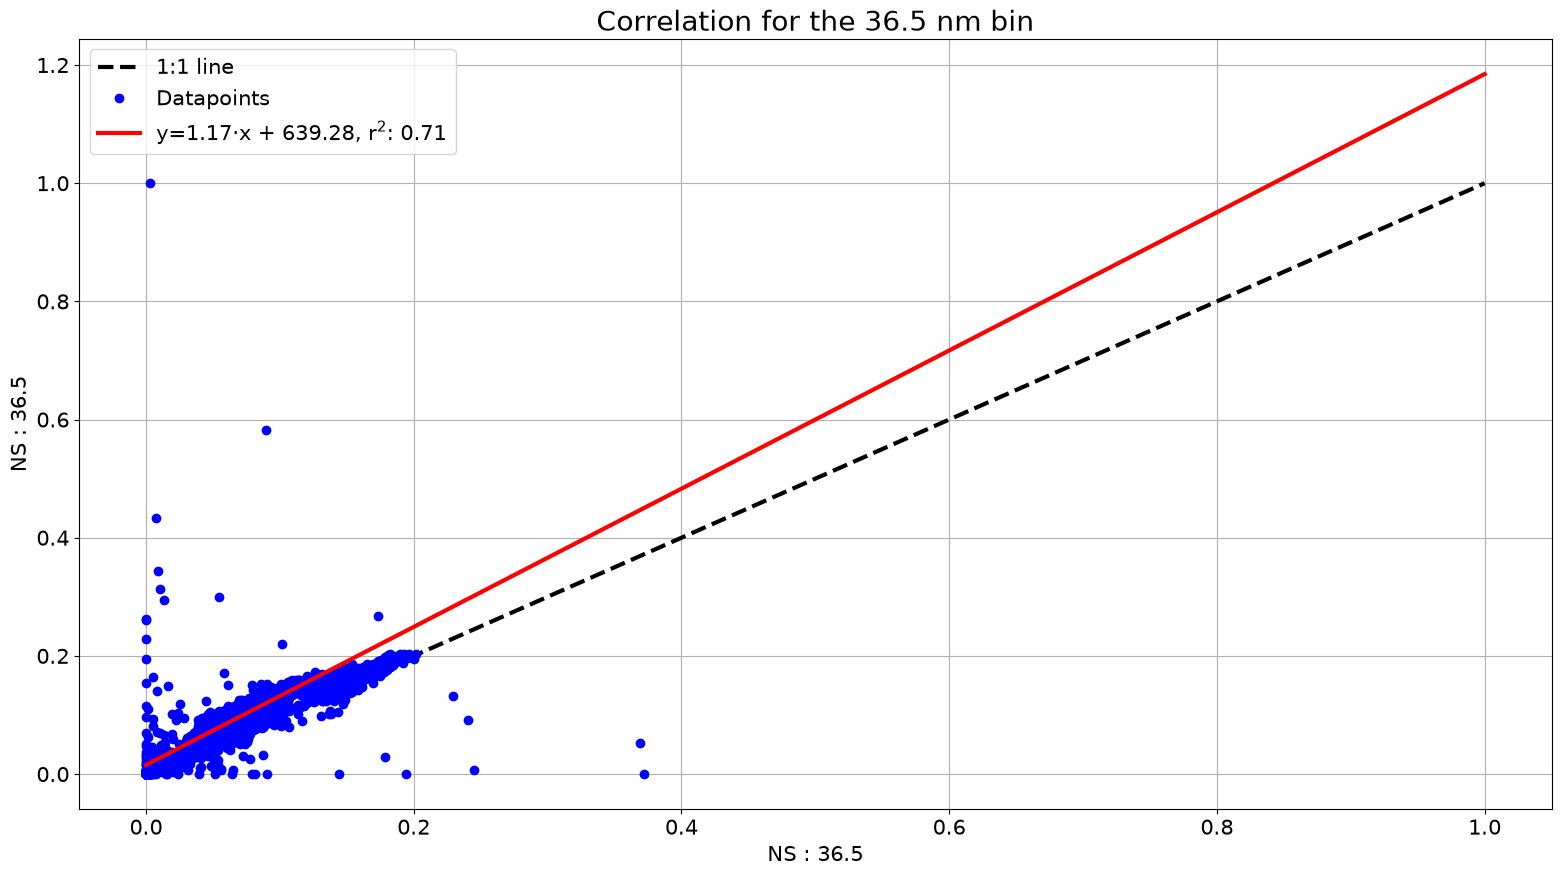

In [4]:
fig, ax = at.plot_correlation(
    ns1, ns2, parameter="36.5",
    match="nearest", tolerance="45s",
    intercept=False, outlier_influence=False,
)
ax.set_title("Correlation for the 36.5 nm bin")

Two arguments control the fit itself:

- `intercept=False` forces the regression through the origin, which is right
  when zero should mean zero for both instruments.
- `outlier_influence=False` drops the diagnostic of how strongly individual
  points pull the fit.

Columns in `.extra_data` work the same way.

In [5]:
list(ns1.extra_data)

['Median',
 'Mean',
 'Geo Mean',
 'Mode',
 'GSD',
 'Particle Density (g/cc)',
 'Firmware Version',
 'Status']

Text(0.5, 1.0, 'Correlation of the median diameter')

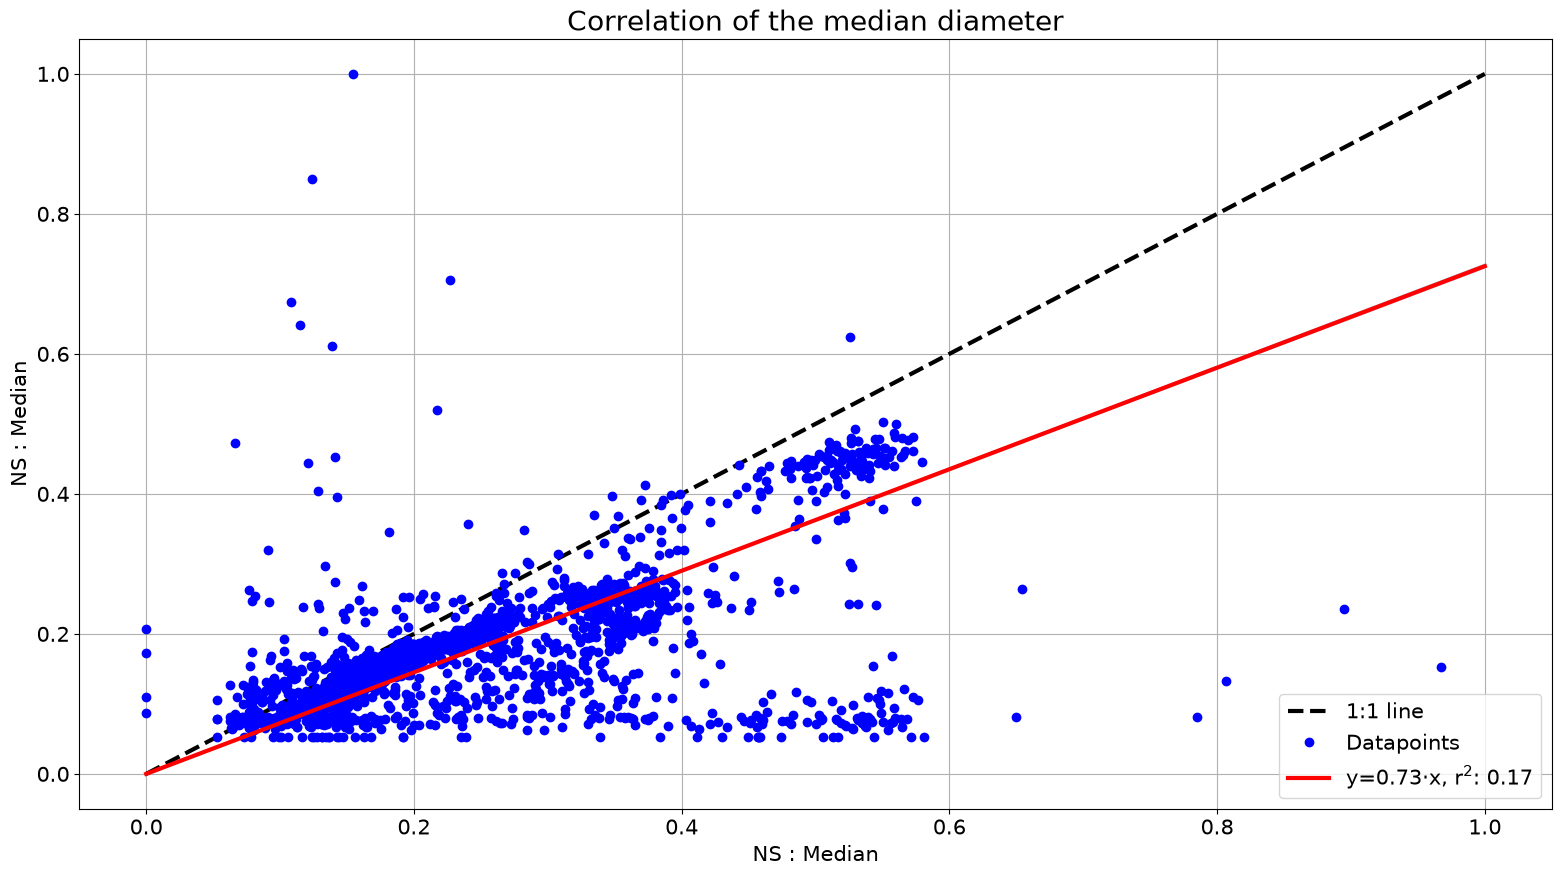

In [6]:
fig, ax = at.plot_correlation(
    ns1, ns2, parameter="Median",
    match="nearest", tolerance="45s", intercept=False,
)
ax.set_title("Correlation of the median diameter")

## Bland-Altman: agreement, not correlation

A high R² only says two instruments move together — it does not say they
*agree*. An instrument reading twice another correlates perfectly. Bland-Altman
plots the difference between the two against their mean, which exposes a
constant offset or a difference that grows with concentration.

/home/runner/work/aerosoltools/aerosoltools/src/aerosoltools/intercomparison/correlation.py:538: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=15)


For the differences, μ = -2259.33 cm⁻³ and s = 7328.13 cm⁻³


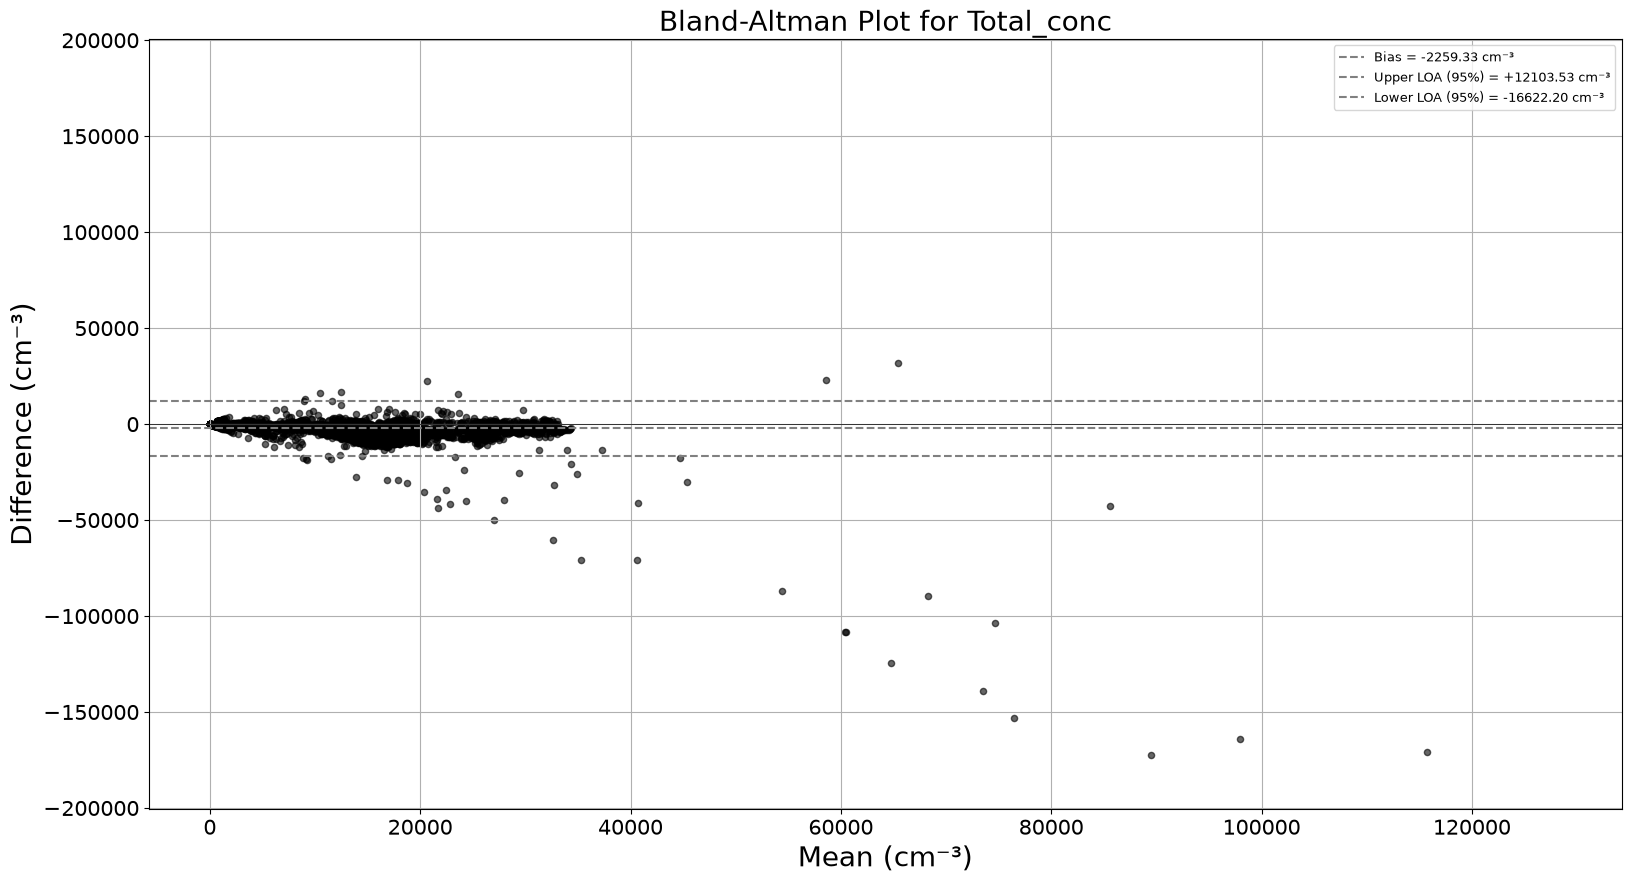

In [7]:
fig, ax = at.bland_altman_analysis(ns1, ns2, match="nearest", tolerance="45s")

The centre line is the mean difference (the bias) and the outer lines are the
limits of agreement. A trend across the x-axis means the disagreement is
concentration-dependent, which a single scaling factor cannot fix.

`C` sets the confidence level for the limits.

For the differences, μ = -2259.33 cm⁻³ and s = 7328.13 cm⁻³


/home/runner/work/aerosoltools/aerosoltools/src/aerosoltools/intercomparison/correlation.py:538: UserWarning: No artists with labels found to put in legend.  Note that artists whose label start with an underscore are ignored when legend() is called with no argument.
  ax.legend(fontsize=15)


Text(0.5, 1.0, 'Bland-Altman with 99% limits of agreement')

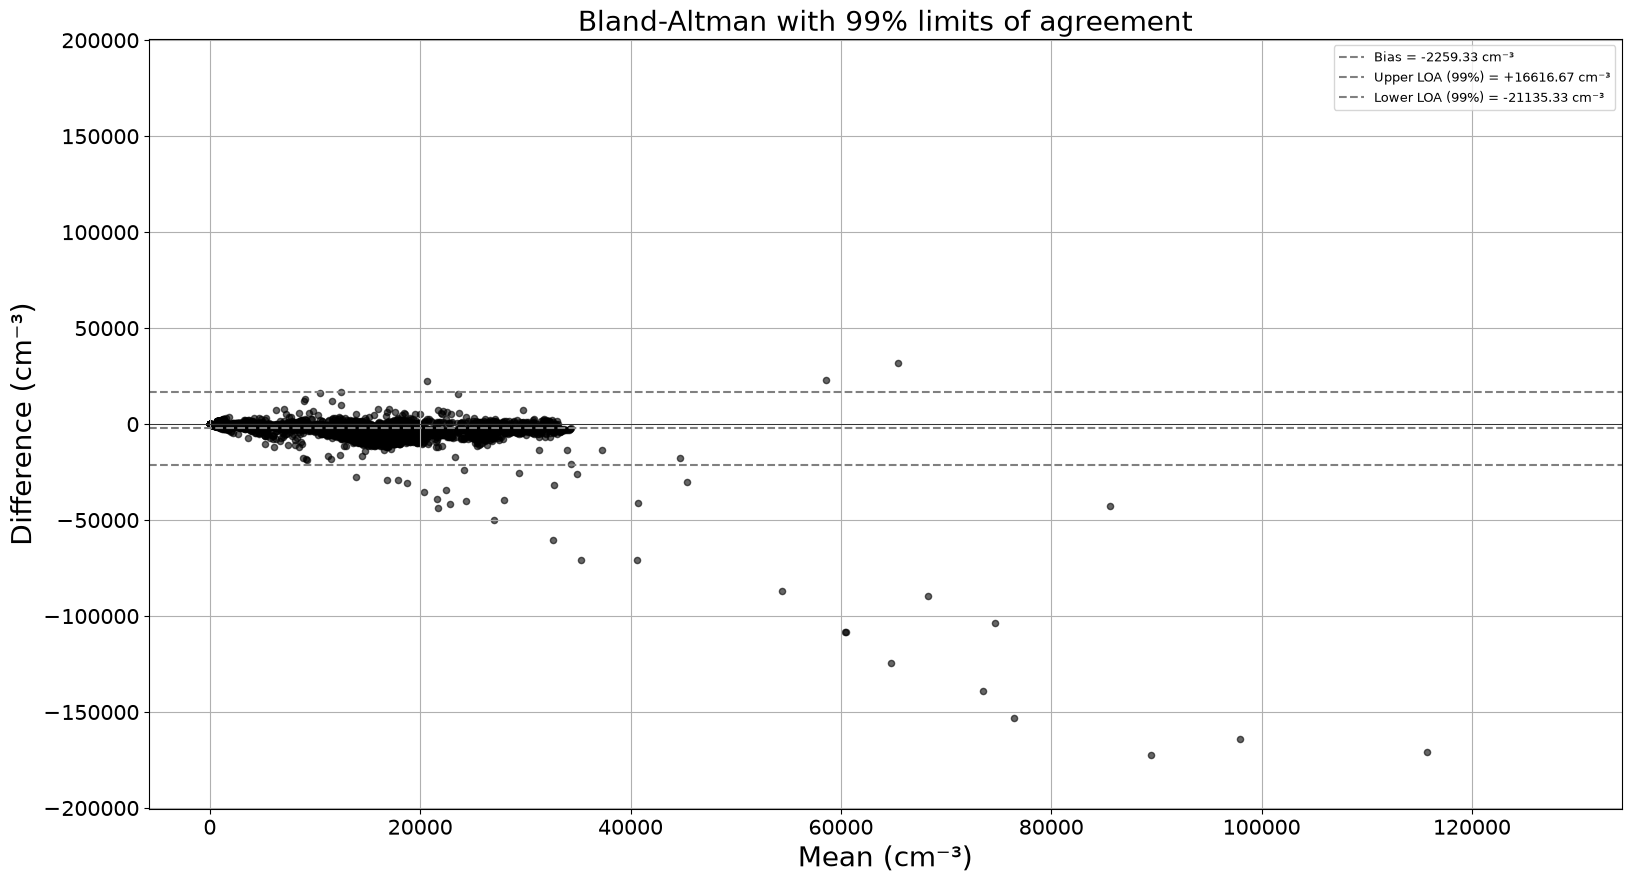

In [8]:
fig, ax = at.bland_altman_analysis(
    ns1, ns2, C=0.99, match="nearest", tolerance="45s",
)
ax.set_title("Bland-Altman with 99% limits of agreement")

## Fitting a relationship

`fit_data` returns the fitted parameters rather than a plot. It needs the two
series on shared timestamps, so rebin both to a common grid first.

In [9]:
a = ns1.timerebin("1min", inplace=False)
b = ns2.timerebin("1min", inplace=False)

params, errors, r_squared = at.fit_data(a, b, parameter="Total_conc")

print(f"slope    : {params['m']:.4f} +/- {errors['m']:.4f}")
print(f"R squared: {r_squared}")

slope    : 1.2009 +/- 0.0073
R squared: 0.559


By default it fits a proportional relationship, `y = m * x`. Supply your own
`fit_function` and a starting guess for each of its parameters to fit something
else.

In [10]:
def linear(x, m, b):
    return m * x + b


params, errors, r_squared = at.fit_data(
    a, b, parameter="Total_conc",
    fit_function=linear,
    variable_guess={"m": 1.0, "b": 0.0},
)

print(f"slope     : {params['m']:.4f} +/- {errors['m']:.4f}")
print(f"intercept : {params['b']:.1f} +/- {errors['b']:.1f}")
print(f"R squared : {r_squared}")

slope     : 1.0442 +/- 0.0125
intercept : 2746.0 +/- 179.7
R squared : 0.578


A slope near 1 with an intercept near 0 means the instruments agree. This one
reads about 20% high — which is exactly the situation
[10b — Calibration](10b-calibration.ipynb) corrects.

---

**Next:** [10b — Calibration](10b-calibration.ipynb).